In [28]:
import glob

results = glob.glob(r'C:\Users\hp\**\diabetes.csv', recursive=True)
print(results)

['C:\\Users\\hp\\Downloads\\diabetes.csv']


In [29]:
import pandas as pd
df = pd.read_csv(r'C:\\Users\\hp\\Downloads\\diabetes.csv')

In [30]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [32]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [33]:
df.duplicated().sum()



np.int64(0)

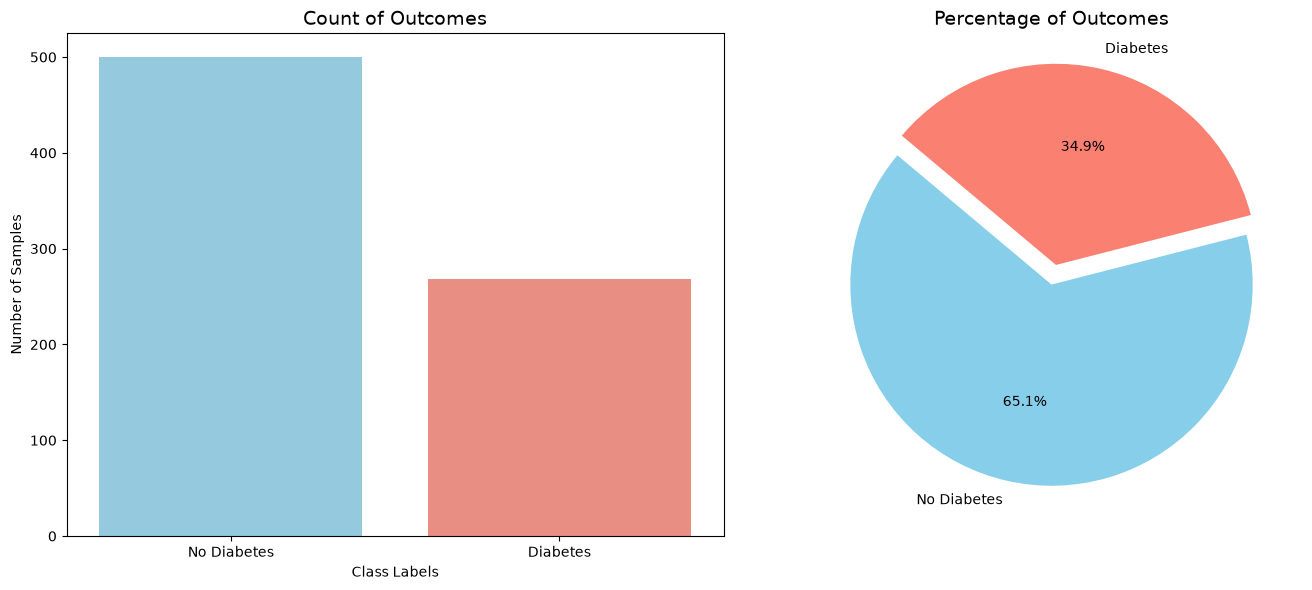

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = ['skyblue', 'salmon']  # 0 = No Diabetes, 1 = Diabetes

plt.figure(figsize=(14, 6))

# Count plot
plt.subplot(1, 2, 1)
sns.countplot(x='Outcome', data=df, hue='Outcome', palette=colors, legend=False)
plt.title("Count of Outcomes", fontsize=14)
plt.xlabel('Class Labels')
plt.ylabel('Number of Samples')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])

# Pie chart
plt.subplot(1, 2, 2)
outcome_counts = df['Outcome'].value_counts().sort_index()
plt.pie(outcome_counts, labels=['No Diabetes', 'Diabetes'], autopct='%1.1f%%',
        colors=colors, startangle=140, explode=(0, 0.1))
plt.title("Percentage of Outcomes", fontsize=14)

plt.tight_layout()
plt.show()


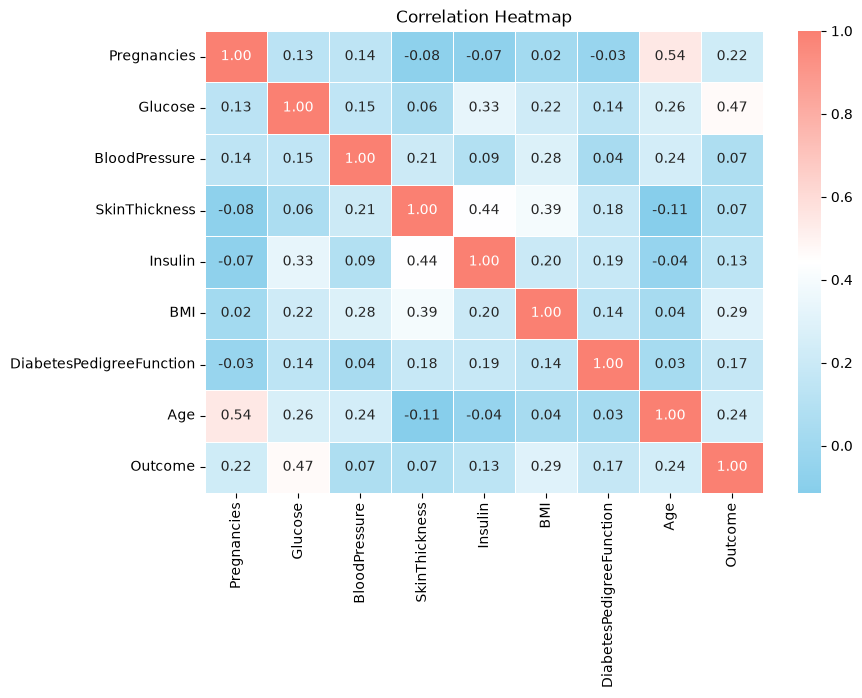

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Custom colormap matching our scheme: skyblue -> white -> salmon
our_cmap = LinearSegmentedColormap.from_list('skyblue_salmon', ['skyblue', 'white', 'salmon'])

plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True, cmap=our_cmap, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


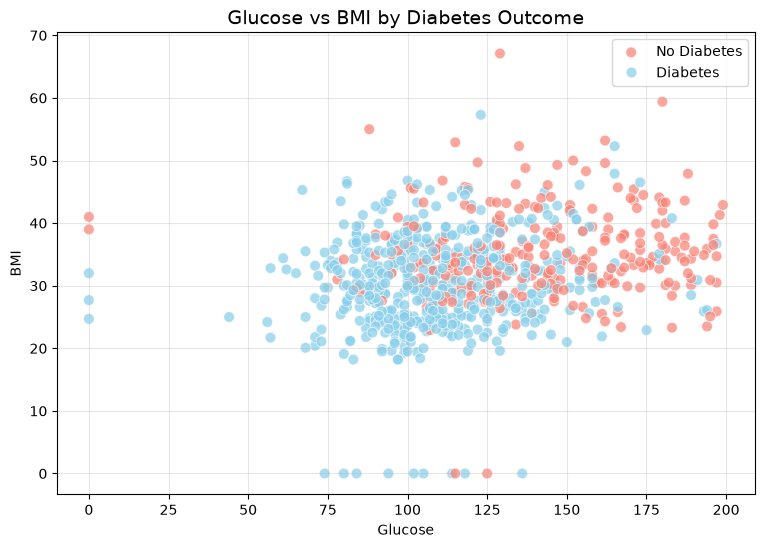

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = {0: 'skyblue', 1: 'salmon'}  # No Diabetes / Diabetes

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x='Glucose', y='BMI',
    hue='Outcome', palette=colors,
    alpha=0.7, s=60, edgecolor='white'
)
plt.title('Glucose vs BMI by Diabetes Outcome', fontsize=14)
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.legend(title='', labels=['No Diabetes', 'Diabetes'])
plt.grid(True, alpha=0.3)
plt.show()


In [37]:

num_cols = df.select_dtypes(include='number').columns
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_mask = (df[num_cols] < lower) | (df[num_cols] > upper)

print('Outliers per column:')
print(outlier_mask.sum())

outlier_rows = df[outlier_mask.any(axis=1)]
print(f'\nTotal rows with at least one outlier: {len(outlier_rows)}')
outlier_rows

Outliers per column:
Pregnancies                  4
Glucose                      5
BloodPressure               45
SkinThickness                1
Insulin                     34
BMI                         19
DiabetesPedigreeFunction    29
Age                          9
Outcome                      0
dtype: int64

Total rows with at least one outlier: 129


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
4,0,137,40,35,168,43.1,2.288,33,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1
12,10,139,80,0,0,27.1,1.441,57,0
...,...,...,...,...,...,...,...,...,...
706,10,115,0,0,0,0.0,0.261,30,1
707,2,127,46,21,335,34.4,0.176,22,0
710,3,158,64,13,387,31.2,0.295,24,0
715,7,187,50,33,392,33.9,0.826,34,1


In [38]:
df_clean = df[~outlier_mask.any(axis=1)]

print(f'Before: {len(df)} rows')
print(f'After:  {len(df_clean)} rows')
print(f'Removed: {len(df) - len(df_clean)} outlier rows')
df_clean

Before: 768 rows
After:  639 rows
Removed: 129 outlier rows


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
5,5,116,74,0,0,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [39]:

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)


In [40]:
df_clean.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
5,5,116,74,0,0,25.6,0.201,30,0


In [41]:
df_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.461538,0.675325,0.500000,0.583333,0.000000,0.484277,0.493261,0.644444,1.0
1,0.076923,0.266234,0.411765,0.483333,0.000000,0.264151,0.245283,0.222222,0.0
2,0.615385,0.902597,0.382353,0.000000,0.000000,0.160377,0.533693,0.244444,1.0
3,0.076923,0.292208,0.411765,0.383333,0.295597,0.311321,0.079964,0.000000,0.0
4,0.384615,0.467532,0.529412,0.000000,0.000000,0.232704,0.110512,0.200000,0.0


In [42]:
from sklearn.model_selection import train_test_split

X = df_scaled.drop('Outcome', axis=1)
y = df_scaled['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} rows')
print(f'Test:  {X_test.shape[0]} rows')


Train: 511 rows
Test:  128 rows


In [43]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



# Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict & evaluate
y_train_pred=model.predict(X_train)
y_validation_pred=model.predict(X_val)
y_test_pred=model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_train_pred , y_train):.3f}\n')
print(f'Accuracy: {accuracy_score(y_validation_pred , y_val):.3f}\n')
print(f'Accuracy: {accuracy_score(y_test_pred , y_test):.3f}\n')

print('Confusion matrix:')
print(confusion_matrix(y_test, y_test_pred))

print('\nClassification report:')
print(classification_report(y_test, y_test_pred))

Accuracy: 0.775

Accuracy: 0.796

Accuracy: 0.781

Confusion matrix:
[[81  7]
 [21 19]]

Classification report:
              precision    recall  f1-score   support

         0.0       0.79      0.92      0.85        88
         1.0       0.73      0.47      0.58        40

    accuracy                           0.78       128
   macro avg       0.76      0.70      0.71       128
weighted avg       0.77      0.78      0.77       128



In [45]:
import numpy as np
probs = model.predict_proba(X_test)
confidences = probs.max(axis=1)
print(f"First 5 confidence scores: {confidences[:5]}")
proba_df = pd.DataFrame(probs, columns=model.classes_)
print(proba_df.head())

First 5 confidence scores: [0.79284472 0.87436684 0.8772222  0.83341117 0.80759318]
        0.0       1.0
0  0.792845  0.207155
1  0.874367  0.125633
2  0.877222  0.122778
3  0.833411  0.166589
4  0.807593  0.192407


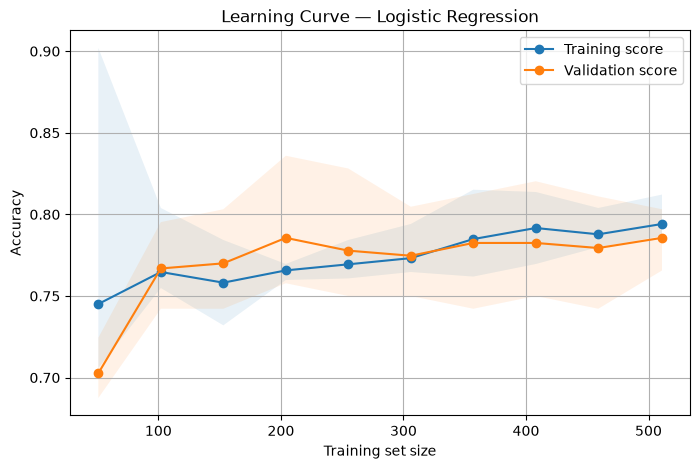

In [46]:

import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Pipeline so scaling is re-fit inside each CV fold (no leakage)
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

train_sizes, train_scores, val_scores = learning_curve(
    logreg, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training score')
plt.plot(train_sizes, val_mean, 'o-', label='Validation score')
plt.fill_between(train_sizes, train_scores.min(axis=1), train_scores.max(axis=1), alpha=0.1)
plt.fill_between(train_sizes, val_scores.min(axis=1), val_scores.max(axis=1), alpha=0.1)
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve — Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()


In [47]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale so coefficients are comparable across features

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Rank features by absolute coefficient magnitude
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0],
    'Importance': abs(model.coef_[0])
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(importance)


                    Feature  Coefficient  Importance
0                   Glucose     3.921223    3.921223
1                       BMI     2.007714    2.007714
2                       Age     1.149593    1.149593
3               Pregnancies     1.027652    1.027652
4  DiabetesPedigreeFunction     0.848733    0.848733
5             SkinThickness     0.259565    0.259565
6                   Insulin    -0.061331    0.061331
7             BloodPressure    -0.015385    0.015385


In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

keep = ['Glucose', 'BMI', 'Pregnancies', 'DiabetesPedigreeFunction', 'Age']

X_train_sel = X_train[keep]
X_test_sel = X_test[keep]



model = LogisticRegression(max_iter=1000)
model.fit(X_train_sel, y_train)

y_pred = model.predict(X_test_sel)
print(f'Accuracy (top 5 features): {accuracy_score(y_test, y_pred):.3f}')
print(classification_report(y_test, y_pred))


Accuracy (top 5 features): 0.773
              precision    recall  f1-score   support

         0.0       0.79      0.91      0.85        88
         1.0       0.70      0.47      0.57        40

    accuracy                           0.77       128
   macro avg       0.75      0.69      0.71       128
weighted avg       0.76      0.77      0.76       128



In [49]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# The 5 features your model/app use
keep = ['Glucose', 'BMI', 'Pregnancies', 'DiabetesPedigreeFunction', 'Age']

X = df_clean[keep]        # features only — no Outcome
y = df_clean['Outcome']   # target kept out of scaling

# Split first, then fit the scaler on training data only (no leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=keep)
X_test  = pd.DataFrame(scaler.transform(X_test),  columns=keep)


In [50]:
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense
#import tensorflow as tf

In [51]:
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense, Dropout

#model = Sequential([
    #Dense(32, activation='relu', input_shape=(X_train.shape[1],)),  # auto-matches feature count
    #Dropout(0.3),
    #Dense(16, activation='relu'),
    #Dropout(0.3),
    #Dense(1, activation='sigmoid') 
#])

#model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [52]:
#model.fit(
    #X_train, y_train,
    #validation_data=(X_test, y_test),   # needed so val_accuracy exists
    #epochs=250,
#)


In [53]:
#loss , acc = model.evaluate(X_test , y_test)
#acc

In [54]:

import joblib
joblib.dump(scaler, 'diabetes_scaler.pkl')
joblib.dump(model, 'diabetes_model.pkl')
print("Saved!")

Saved!
